`conda activate cellcharter`

Adapted from https://github.com/christophhmayr/2023_Mayr/blob/main/final_cytassist_human_visium_integrate_frequencies.ipynb <br>
Paper: https://doi.org/10.1126/sciadv.adl5473

In [ ]:
import anndata as ad
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io
import os
import cell2location

In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('sp.h5ad')

In [ ]:
# Exclude sample that contains a significant portion of healthy tissue (cerebellar region)
adata = adata[ ~adata.obs['sample'].isin(['DMG1'])].copy()
adata

AnnData object with n_obs × n_vars = 11848 × 15284
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '_indices', '_scvi_batch', '_scvi_labels', 'AC_like', 'Astrocyte', 'B_cell', 'COP_like', 'Cilia_like', 'Endothelial', 'GB_like', 'GW_like', 'Mono_neutrophil', 'Mural', 'Neuron', 'OPC', 'OPC_like', 'Oligodendrocyte', 'RG_like', 'TAM_C1Q', 'TAM_IL1B', 'TAM_homeostatic', 'TAM_lipid_laden', 'TAM_scavenger', 'TD_like', 'T_cell', 'Tri_IPC_like', 'nIPC_like', 'total RNA counts', 'Total cell abundance (sum_f w_sf)', 'RNA detection sensitivity (y_s)', 'mean_nUMI_factorsfact_0', 'mean_nUMI_factorsfact_1', 'mean_nUMI_factorsfact_2', 'mean_nUMI_factorsfact_3', 'mean_nUMI_factorsfact_4', 'mean_nUMI_factorsfact_5', 'mean_nUMI_factorsfact_6', 'mean_nUMI_factorsfact_7', 'mean_nUMI_factorsf

In [ ]:
nmf_df = pd.DataFrame(adata.uns['mod_coloc_n_fact7']['post_sample_means']['location_factors'])
nmf_df.index = adata.uns['mod_coloc_n_fact7']['obs_names']
nmf_df.columns = adata.uns['mod_coloc_n_fact7']['fact_names']
nmf_df.head()

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.0,0.000000,0.0,0.083814,0.226187,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.0,0.038803,0.0,0.103664,0.114554,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.0,0.000000,0.0,0.120920,0.097331,0.0,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.0,0.023437,0.0,0.110779,0.048015,0.0,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.0,0.000000,0.0,0.098536,0.408341,0.0,0.000000


In [ ]:
# Ensure that 'nmf_df' index and 'adata.obs_names' are aligned in type (e.g., strings)
nmf_df = nmf_df.loc[adata.obs_names]
nmf_df

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6
spot_id,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.000000,0.000000,0.000000,0.083814,0.226187,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.000000,0.038803,0.000000,0.103664,0.114554,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.000000,0.000000,0.000000,0.120920,0.097331,0.0,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.000000,0.023437,0.000000,0.110779,0.048015,0.0,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.000000,0.000000,0.000000,0.098536,0.408341,0.0,0.000000
...,...,...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,0.019947,0.923844,0.318662,0.067453,0.133061,0.0,0.000000
DMG5_TTGTTCAGTGTGCTAC-1,0.036767,0.000000,0.000000,0.000000,1.568617,0.0,0.000000
DMG5_TTGTTGTGTGTCAAGA-1,0.070362,0.163486,0.030180,0.002634,0.596495,0.0,0.000000


In [ ]:
nmf_df = nmf_df.loc[:,['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]
nmf_df

,fact_0,fact_2,fact_4,fact_1,fact_6
spot_id,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.000000,0.000000,0.226187,0.000000,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.000000,0.000000,0.114554,0.038803,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.000000,0.000000,0.097331,0.000000,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.000000,0.000000,0.048015,0.023437,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.000000,0.000000,0.408341,0.000000,0.000000
...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,0.019947,0.318662,0.133061,0.923844,0.000000
DMG5_TTGTTCAGTGTGCTAC-1,0.036767,0.000000,1.568617,0.000000,0.000000
DMG5_TTGTTGTGTGTCAAGA-1,0.070362,0.030180,0.596495,0.163486,0.000000


In [ ]:
nmf_normalized = nmf_df.div(nmf_df.sum(axis=1), axis=0)
nmf_normalized

,fact_0,fact_2,fact_4,fact_1,fact_6
spot_id,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.000000,0.000000,1.000000,0.000000,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.000000,0.000000,0.746977,0.253023,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.000000,0.000000,0.825575,0.000000,0.174425
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.000000,0.000000,0.197542,0.096423,0.706035
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.000000,0.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,0.014294,0.228348,0.095349,0.662010,0.000000
DMG5_TTGTTCAGTGTGCTAC-1,0.022902,0.000000,0.977098,0.000000,0.000000
DMG5_TTGTTGTGTGTCAAGA-1,0.081767,0.035071,0.693177,0.189985,0.000000


In [ ]:
xy_df = pd.DataFrame(adata.obsm['spatial'], columns=['x', 'y'])
xy_df.index = adata.obs_names  # Match row names with observation names

xy_output_path = "spatial_data.csv"
nmf_output_path = "nmf_data.csv"

xy_df.to_csv(xy_output_path)
nmf_normalized.to_csv(nmf_output_path)

In [ ]:
nmf_df['max_factor'] = nmf_df.idxmax(axis=1)
nmf_df.head()

,fact_0,fact_2,fact_4,fact_1,fact_6,max_factor
spot_id,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.0,0.0,0.226187,0.000000,0.000000,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.0,0.0,0.114554,0.038803,0.000000,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.0,0.0,0.097331,0.000000,0.020564,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.0,0.0,0.048015,0.023437,0.171610,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.0,0.0,0.408341,0.000000,0.000000,fact_4


In [ ]:
if (nmf_df.index == adata.obs_names).all():
    print("Indexes match!")
else:
    print("Warning: Indexes do not match, please reorder or check!")

adata.obs['max_factor'] = nmf_df['max_factor'].values

adata.obs.head()

Indexes match!


,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,mean_nUMI_factorsfact_12,mean_nUMI_factorsfact_13,mean_nUMI_factorsfact_14,max_factor
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,1,73,43,BT01_192_core_HE,3845,8.254789,9634.0,9.173158,21.351464,28.139921,...,1.478956,0.000000,0.0,0.0,0.000000,0.522885,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,1,42,28,BT01_192_core_HE,3607,8.190909,9569.0,9.166389,23.910544,31.476643,...,1.563863,0.005317,0.0,0.0,0.088299,0.140116,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,1,52,42,BT01_192_core_HE,3303,8.102889,8040.0,8.992309,23.644279,30.472637,...,1.755234,0.065163,0.0,0.0,0.000000,0.053763,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,1,37,19,BT01_192_core_HE,2716,7.907284,6225.0,8.736489,23.180723,30.907631,...,0.837298,0.508212,0.0,0.0,0.054470,0.000000,0.0,0.054273,0.0,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,1,35,79,BT01_192_core_HE,1491,7.307873,2782.0,7.931285,26.491733,34.974838,...,0.168988,0.000000,0.0,0.0,0.000000,1.428918,0.0,0.111628,0.0,fact_4


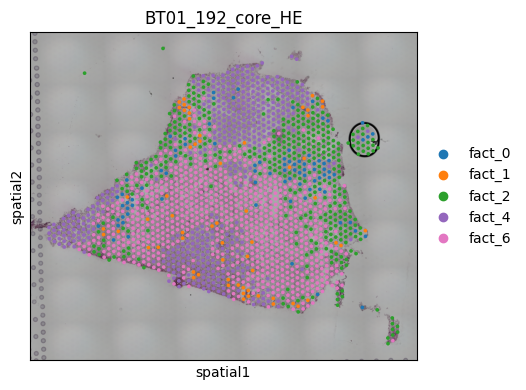

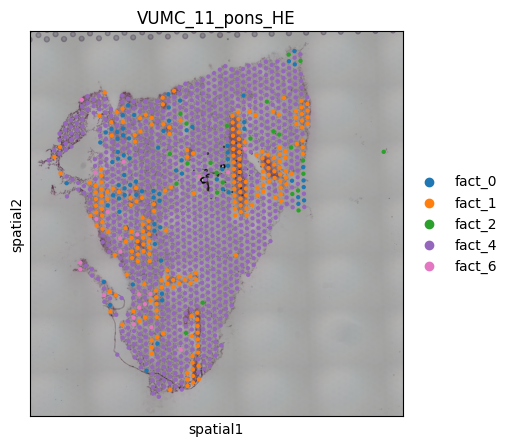

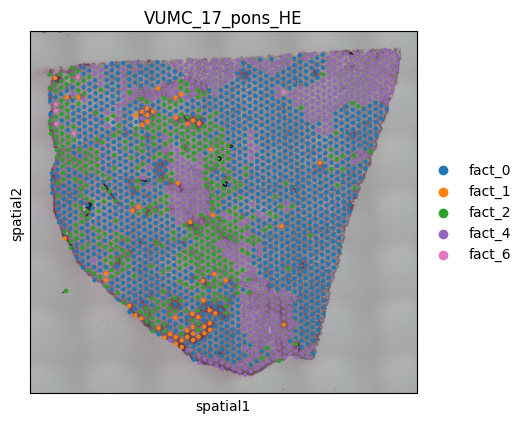

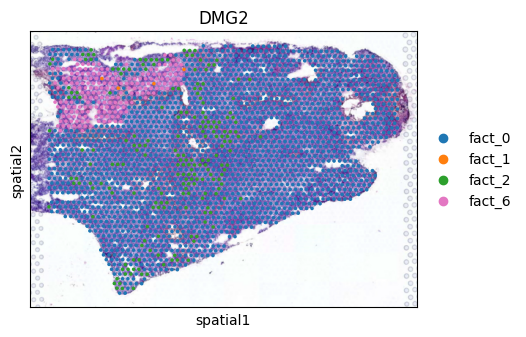

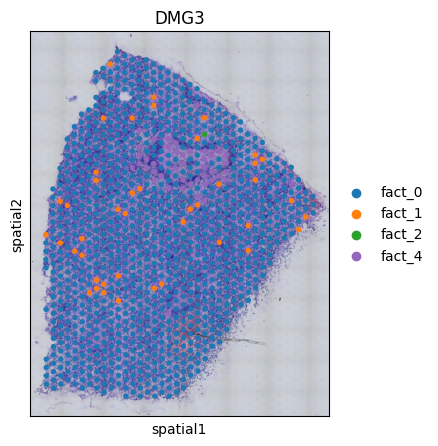

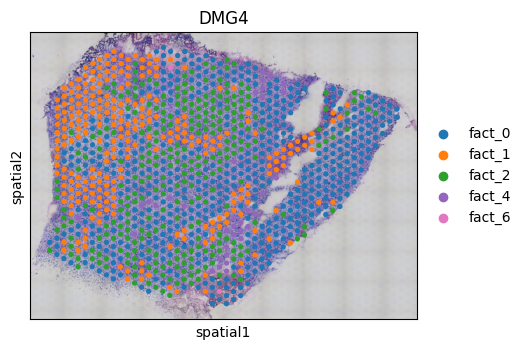

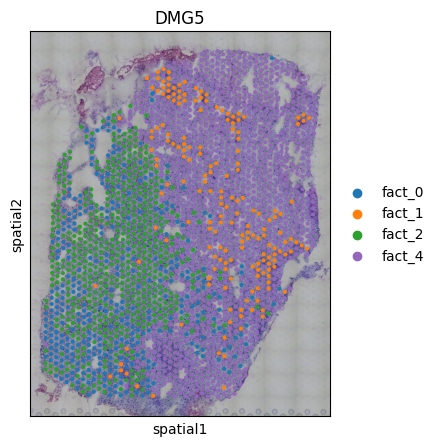

In [ ]:
from cell2location.utils import select_slide

sample_library_dict = {
    'BT01_192_core_HE': 'BT01_192_core_HE/outs/',
    'VUMC_17_pons_HE': 'VUMC_17_pons_HE/outs/',
    'VUMC_11_pons_HE': 'VUMC_11_pons_HE/outs/'
}

factor_palette = {
    'fact_0': '#1f77b4',  # blue
    'fact_1': '#ff7f0e',  # orange
    'fact_2': '#2ca02c',  # green
    'fact_3': '#d62728',  # red
    'fact_4': '#9467bd',  # purple
    'fact_5': '#8c564b',  # brown
    'fact_6': '#e377c2'   # pink
}

# Plot niches
for sample in adata.obs['sample'].unique():

    slide = select_slide(adata, sample)
    
    if sample in sample_library_dict:
        library_id = sample_library_dict[sample]
        spatial_key = "spatial"
        slide.uns['spatial_slide'] = slide.uns[spatial_key]  
        slide.uns[spatial_key] = {library_id: {}}  
        slide.uns[spatial_key][library_id] = slide.uns['spatial_slide'][sample]["outs"] 
    sc.pl.spatial(
        slide, 
        color=['max_factor'], 
        palette=factor_palette,  #
        title=sample
    )

In [ ]:
# save figures
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

for sample in adata.obs['sample'].unique():

    slide = select_slide(adata, sample)
  
    if sample in sample_library_dict:
        library_id = sample_library_dict[sample]
        spatial_key = "spatial"
        slide.uns['spatial_slide'] = slide.uns[spatial_key]  # Backup original spatial info
        slide.uns[spatial_key] = {library_id: {}}  # Set up the new spatial dictionary
        slide.uns[spatial_key][library_id] = slide.uns['spatial_slide'][sample]["outs"]  # Update with correct library_id

    if not isinstance(slide.obs['max_factor'].dtype, pd.CategoricalDtype):
        slide.obs['max_factor'] = slide.obs['max_factor'].astype('category')
    

    factors_in_sample = slide.obs['max_factor'].cat.categories
  
    palette_list = []
    for factor in factors_in_sample:
        if factor in factor_palette:
            palette_list.append(factor_palette[factor])  
        else:
            palette_list.append("#000000") 
    
    listed_cmap = ListedColormap(palette_list)

    slide.uns['factor_palette'] = listed_cmap

    sq.pl.spatial_scatter(
        slide, 
        shape='hex',
        color='max_factor',  
        palette=listed_cmap,
        img_alpha=0,
        title=sample,
        size=1.5
    )
    
    plt.savefig(f'figures/cell2location_niches_{sample}.pdf', bbox_inches='tight')  
    plt.close() 

In [ ]:
cts = ['RG_like','Tri_IPC_like','nIPC_like','OPC_like', # Stem-enriched
      'COP_like','AC_like','TAM_scavenger','TAM_homeostatic','OPC', #AC/MG
      'TD_like','GW_like','GB_like', 'TAM_lipid_laden','TAM_C1Q', # hypoxia/stress
      'Mono_neutrophil','Neuron','B_cell','Cilia_like',
      'Endothelial','Mural', 'TAM_IL1B','T_cell', # Vascular
      'Oligodendrocyte', 'Astrocyte']

In [ ]:
# Define the samples classified as 'relapse' and 'diagnosis'
relapse_samples = ['BT01_192_core_HE', 'VUMC_17_pons_HE', 'VUMC_11_pons_HE']

adata.obs['treatment'] = adata.obs['sample'].apply(lambda x: 'relapse' if x in relapse_samples else 'diagnosis')

## Within niche and clinical status

In [ ]:
adata.obs['sampleID'] = adata.obs['sample']

adata.obs['Niche_NMF'] = adata.obs['max_factor']

In [ ]:
tab = sc.get.obs_df(adata, keys= ["sampleID","Niche_NMF","treatment"]+ cts)
tab

,sampleID,Niche_NMF,treatment,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,BT01_192_core_HE,fact_4,relapse,0.021343,0.000577,0.000264,0.003829,0.049919,0.037373,0.111147,...,0.000898,0.001166,0.000685,0.003585,0.010324,0.013355,0.007721,0.001446,0.066556,0.005033
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,BT01_192_core_HE,fact_4,relapse,0.146086,0.000589,0.000110,0.000441,0.009161,0.014664,0.001914,...,0.008610,0.002127,0.103529,0.031192,0.001841,0.147082,0.000674,0.001893,0.001790,0.046993
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,BT01_192_core_HE,fact_4,relapse,0.034471,0.001196,0.000193,0.001001,0.065087,0.085740,0.030406,...,0.001099,0.001679,0.001018,0.112046,0.000144,0.049133,0.000832,0.001089,0.000950,0.021041
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,BT01_192_core_HE,fact_6,relapse,0.037238,0.000351,0.000052,0.000127,0.000589,0.010911,0.016402,...,0.001963,0.016388,0.081774,0.359850,0.000051,0.180938,0.002721,0.000327,0.001238,0.136919
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,BT01_192_core_HE,fact_4,relapse,0.002676,0.001632,0.001150,0.002234,0.013317,0.055440,0.004203,...,0.003271,0.019448,0.001879,0.033703,0.000720,0.006513,0.002155,0.001038,0.005949,0.206932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,DMG5,fact_1,diagnosis,0.601690,0.235197,0.006226,0.164946,0.081588,0.811372,0.031711,...,0.021417,0.001853,0.006854,0.003325,0.721555,1.579541,0.009543,0.045397,0.001212,0.040396
DMG5_TTGTTCAGTGTGCTAC-1,DMG5,fact_4,diagnosis,0.066690,0.000274,0.746098,0.001578,0.000060,0.000912,0.000586,...,0.073587,0.000119,0.010735,0.000128,0.001907,0.017348,0.000950,0.002308,0.000079,0.000997
DMG5_TTGTTGTGTGTCAAGA-1,DMG5,fact_4,diagnosis,0.418019,0.003589,0.005182,0.253150,0.001706,0.147704,0.143137,...,0.048729,0.000885,0.028702,0.004498,0.201910,0.351810,0.071725,0.011518,0.000801,0.023155


In [ ]:
ct_label = "cell_type"
group_by = "sampleID"
xlabel = "Niche_NMF"
ctss = cts
#cm = "sampleID"

tab = tab.loc[:, ctss + [xlabel]].copy()
tab.head()

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte,Niche_NMF
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.021343,0.000577,0.000264,0.003829,0.049919,0.037373,0.111147,0.003073,0.088800,0.375909,...,0.001166,0.000685,0.003585,0.010324,0.013355,0.007721,0.001446,0.066556,0.005033,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.146086,0.000589,0.000110,0.000441,0.009161,0.014664,0.001914,0.000790,0.003248,0.077121,...,0.002127,0.103529,0.031192,0.001841,0.147082,0.000674,0.001893,0.001790,0.046993,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.034471,0.001196,0.000193,0.001001,0.065087,0.085740,0.030406,0.001394,0.029888,0.071013,...,0.001679,0.001018,0.112046,0.000144,0.049133,0.000832,0.001089,0.000950,0.021041,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.037238,0.000351,0.000052,0.000127,0.000589,0.010911,0.016402,0.007284,0.003260,0.021919,...,0.016388,0.081774,0.359850,0.000051,0.180938,0.002721,0.000327,0.001238,0.136919,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.002676,0.001632,0.001150,0.002234,0.013317,0.055440,0.004203,0.001130,0.013768,1.005547,...,0.019448,0.001879,0.033703,0.000720,0.006513,0.002155,0.001038,0.005949,0.206932,fact_4


In [ ]:
test_tab2 = tab.copy()

In [ ]:
## Calculate the mean per cell type and compartment
test_tab = test_tab2.groupby([xlabel]).mean().reset_index()
print(test_tab.shape)
test_tab.head()

(5, 25)


,Niche_NMF,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
0,fact_0,0.402126,0.224424,0.777743,2.410097,0.092057,0.459025,0.042403,0.091559,0.185699,...,0.060231,0.058034,0.024965,0.044131,0.085496,0.059256,0.035594,0.033639,0.028879,0.053180
1,fact_1,0.291679,0.063994,0.131365,0.531097,0.044067,0.276152,0.146550,0.133215,0.150340,...,0.111567,0.054054,0.085083,0.039245,0.925683,1.727156,0.139545,0.094363,0.013054,0.035014
2,fact_2,0.285117,0.111192,0.133265,0.797933,0.171374,1.153603,0.121162,0.158808,0.659049,...,0.038388,0.111007,0.028033,0.070831,0.142842,0.068078,0.061126,0.024279,0.069484,0.099666
3,fact_4,0.239473,0.027745,0.098938,0.174808,0.017339,0.133333,0.062532,0.065704,0.066408,...,0.048100,0.073732,0.043958,0.029682,0.075290,0.169941,0.040457,0.022998,0.037198,0.066056
4,fact_6,0.034658,0.055450,0.192235,0.214921,0.018888,0.282755,0.099089,0.085904,0.059602,...,0.119962,0.307165,0.366644,1.597001,0.040908,0.412997,0.029010,0.030896,0.038759,0.221758


In [ ]:
test_tab.index = test_tab["Niche_NMF"].tolist()
test_tab = test_tab.drop("Niche_NMF", axis=1)
test_tab

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,0.402126,0.224424,0.777743,2.410097,0.092057,0.459025,0.042403,0.091559,0.185699,0.118113,...,0.060231,0.058034,0.024965,0.044131,0.085496,0.059256,0.035594,0.033639,0.028879,0.053180
fact_1,0.291679,0.063994,0.131365,0.531097,0.044067,0.276152,0.146550,0.133215,0.150340,0.520017,...,0.111567,0.054054,0.085083,0.039245,0.925683,1.727156,0.139545,0.094363,0.013054,0.035014
fact_2,0.285117,0.111192,0.133265,0.797933,0.171374,1.153603,0.121162,0.158808,0.659049,0.130247,...,0.038388,0.111007,0.028033,0.070831,0.142842,0.068078,0.061126,0.024279,0.069484,0.099666
fact_4,0.239473,0.027745,0.098938,0.174808,0.017339,0.133333,0.062532,0.065704,0.066408,1.301001,...,0.048100,0.073732,0.043958,0.029682,0.075290,0.169941,0.040457,0.022998,0.037198,0.066056
fact_6,0.034658,0.055450,0.192235,0.214921,0.018888,0.282755,0.099089,0.085904,0.059602,0.075023,...,0.119962,0.307165,0.366644,1.597001,0.040908,0.412997,0.029010,0.030896,0.038759,0.221758


In [ ]:
test_tab2 = test_tab.div(test_tab.sum(axis=0), axis=1)
test_tab2

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,0.320917,0.464834,0.583214,0.583720,0.267820,0.199155,0.089888,0.171078,0.165640,0.055080,...,0.159238,0.096084,0.045500,0.024780,0.067308,0.024311,0.116423,0.163158,0.154127,0.111799
fact_1,0.232775,0.132546,0.098508,0.128631,0.128203,0.119813,0.310661,0.248912,0.134101,0.242500,...,0.294957,0.089494,0.155068,0.022037,0.728759,0.708597,0.456428,0.457683,0.069665,0.073609
fact_2,0.227538,0.230305,0.099933,0.193258,0.498579,0.500507,0.256842,0.296732,0.587860,0.060738,...,0.101490,0.183790,0.051091,0.039773,0.112454,0.027930,0.199934,0.117757,0.370831,0.209526
fact_4,0.191111,0.057466,0.074192,0.042338,0.050445,0.057849,0.132558,0.122767,0.059235,0.606697,...,0.127165,0.122075,0.080115,0.016667,0.059274,0.069722,0.132327,0.111547,0.198523,0.138868
fact_6,0.027659,0.114849,0.144153,0.052053,0.054952,0.122677,0.210051,0.160511,0.053164,0.034985,...,0.317151,0.508558,0.668226,0.896743,0.032205,0.169440,0.094887,0.149855,0.206854,0.466198


In [ ]:
test_tab3 = test_tab2*100
test_tab3

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,32.091735,46.483366,58.321391,58.372045,26.782047,19.915467,8.988813,17.107777,16.564001,5.507959,...,15.923754,9.608415,4.549955,2.478040,6.730789,2.431089,11.642294,16.315845,15.412695,11.179934
fact_1,23.277471,13.254604,9.850830,12.863051,12.820331,11.981254,31.066087,24.891177,13.410094,24.250005,...,29.495684,8.949402,15.506840,2.203659,72.875891,70.859746,45.642841,45.768272,6.966543,7.360852
fact_2,22.753786,23.030528,9.993307,19.325767,49.857950,50.050706,25.684214,29.673246,58.785952,6.073803,...,10.148993,18.378965,5.109088,3.977269,11.245450,2.793037,19.993421,11.775733,37.083094,20.952582
fact_4,19.111135,5.746560,7.419164,4.233805,5.044498,5.784853,13.255802,12.276676,5.923517,60.669693,...,12.716468,12.207457,8.011535,1.666688,5.927357,6.972156,13.232734,11.154651,19.852271,13.886836
fact_6,2.765873,11.484942,14.415307,5.205333,5.495174,12.267719,21.005085,16.051124,5.316435,3.498540,...,31.715101,50.855762,66.822581,89.674343,3.220513,16.943972,9.488711,14.985498,20.685397,46.619797


In [ ]:
test_tab3 = test_tab3[cts]
test_tab3 = test_tab3.loc[['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]

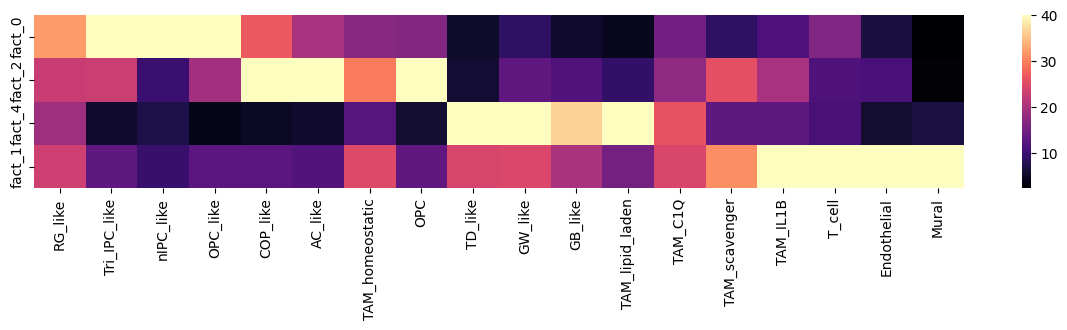

In [ ]:
test_tab3 = test_tab3[cts]
test_tab3 = test_tab3.loc[['fact_0', 'fact_2', 'fact_4', 'fact_1']]
plt.figure(figsize=(15, 2.25))
sb.heatmap(test_tab3, annot=False, cmap="magma", fmt=".0f",linewidths=0, vmax=40)
plt.savefig('figures/heatmap_nmf_cell2loc_pDG_v2.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def standart_lineplot(data, order, xlabel, ylabel, typ = None, gene = None, smooth = None, column = None, cols = None,
                      palette = None, width = 1, title = None, rotation = None, figsize = (15, 5), tick_size = None,
                      label_size = None,
                      order_smooth = 3, legend = None, conf_int = None, scatter = None, save = None):
    
    if smooth: 
        ## Possible to set alpha of scatter with scatter_kws={'alpha': 0.1}
        if typ:
            cat = sb.lmplot(data = data, x = xlabel, y = gene, ci = conf_int, order = order_smooth,
                            scatter = scatter, hue = typ, truncate = True, palette = cols)
        else:
            cat = sb.lmplot(data = data, x = xlabel, y = gene, ci = conf_int, order = order_smooth, scatter = scatter, 
                            palette = cols)
        
    else:
        ## Removed Parameter order = order, as order should be given numerically anyways.
        if typ:
            cat = sb.catplot(data = data, x = xlabel, y = gene, linestyles = "-", kind = "point", hue = typ,
                             palette = cols)
        else:
            cat = sb.catplot(data = data, x = xlabel, y = gene, linestyles = "-", kind = "point", palette = cols)
        if scatter:
            cat2 = sb.stripplot(data = data, x = xlabel, y = gene, palette = ["black"], hue = typ, size = 7)
            if typ:
                cat2.legend_.remove()

    cat.set(xticks = np.unique(data.loc[:, xlabel]))
    
    cat.set_xticklabels(order)
    cat.fig.set_size_inches(figsize)
        
    if rotation:
        cat.ax.set_xticklabels(order, rotation = 'vertical')
    cat.ax.set_title(title, size = label_size)
    cat.ax.set_xlabel(xlabel, size = label_size)
    cat.ax.set_ylabel(ylabel, size = label_size)
    cat.ax.tick_params(labelsize = tick_size)

    if save:
        cat.fig.savefig("%s" %save, bbox_inches = "tight")
        print("Saving figure to %s" %save)
    plt.show()
    plt.close()
    
def split_boxplot(tab, order, xlabel, ylabel, column = None, value = None, cols = None, width = 1, title = None,
                  figsize = (15, 6), legend_loc = None, jitter = None, save = None):
    fig, ax = plt.subplots()
    fig.set_size_inches(figsize)

    if cols is not None:
        fig = sb.boxplot(data = tab, hue = value, x = xlabel, y = column, order = order, width = width, palette = cols)
    else:
        fig = sb.boxplot(data = tab, hue = value, x = xlabel, y = column, order = order, width = width)
    
    if jitter is not None:
        fig = sb.swarmplot(data = tab, color = "black", x = xlabel, y = column, order = order)    
    
    if value is not None:
        plt.legend(loc = legend_loc)
    
    if title:
        fig.set_title(title, size = 15)
        
    fig.set_xlabel(xlabel, size = 15)
    fig.set_ylabel(ylabel, size = 15)
    fig.tick_params(labelsize = 12) 

    if save:
        fig.get_figure().savefig("%s" %(save))
    plt.show()
    plt.close()

## Relative Frequencies
def plot_relFreq(relFreqs, cluster, cols, order, xlabel = "days", condition = "batch", legend_loc = "upper right",
                 figsize = (15,6), width = .5, jitter = None, save = None):
    
    ## Subset according to order
    relFreqs = relFreqs.loc[relFreqs[xlabel].isin(order)]
    
    split_boxplot(relFreqs, order = order, xlabel = xlabel, ylabel = "relative frequency", value = condition,
                  column = cluster, cols = cols, width = width, title = cluster, figsize = figsize,
                  legend_loc = legend_loc, jitter = jitter, save = save)
    
    
## New adapted Version
def calc_relFreq(a, group_by = "cell_type", xlabel = "days", condition = "batch"):
    freqs = a.obs.groupby(["sampleID", group_by]).size()
    samples = np.unique(a.obs["sampleID"])
    ind = a.obs[group_by].cat.categories
    
    relFreqs = [freqs[ident] / sum(freqs[ident]) for ident in samples]
    relFreqs = pd.DataFrame(relFreqs, columns = ind, index = samples).fillna(0)

    #relFreqs[xlabel] = grouping.loc[samples, xlabel]  ## when using Grouping Table
    cell_types = {}
    combis = a.obs.groupby(["sampleID", xlabel]).groups.keys()

    for c in combis:
        cell_types[c[0]] = c[1]
    relFreqs[xlabel] = [cell_types[l] for l in relFreqs.index]

    ## Todo, add for condition
    if condition:
        combis = a.obs.groupby(["sampleID", condition]).groups.keys()
        for c in combis:
            cell_types[c[0]] = c[1]
        relFreqs[condition] = [cell_types[l] for l in relFreqs.index]
    
    return relFreqs

def plot_gene_boxplot(tab, xlabel = "cell_type", condition = None, figsize = (10, 5), legend = True,
                      palette = ["gray", "red", "blue"], score = "Axin2", size = 4, scatter = None,
                      rotate = False, width = 0.7, save = None):
    
    sb.set_style("ticks")  ## show ticks
    fig, ax = plt.subplots()
    fig.set_size_inches(figsize)

    sf = False if scatter else True
    if condition:
        fig = sb.boxplot(data = tab, x = xlabel, y = score, width = width, hue = condition,
                         showfliers = sf, palette = palette)
        if scatter:
            fig = sb.stripplot(data = tab, x = xlabel, y = score, palette = ["black"],
                               size = size, hue = condition, dodge = True)
    else:
        fig = sb.boxplot(data = tab, x = xlabel, y = score, width = width, showfliers = sf, palette = palette)
        if scatter:
            fig = sb.stripplot(data = tab, x = xlabel, y = score, palette = ["black"], size = size, dodge = True)

    if rotate:
        fig.set_xticklabels(fig.get_xticklabels(), rotation = 90)
    else:
        fig.set_xticklabels(fig.get_xticklabels())
    
    if condition:
        ## Remove the dots from the legend if scatter is used
        handles, labels = ax.get_legend_handles_labels()
        n = tab.loc[:, condition].nunique()
        plt.legend(handles[0:n], labels[0:n], bbox_to_anchor=(1.05, 1), loc = 2, borderaxespad = 0.)
    #else:
    #    ax.legend_.remove()
    
    plt.setp(ax.artists, edgecolor = "black")
    plt.setp(ax.lines, color = "black")
    sb.despine()  ## to not show ouline box

    if save:
        print("Saving to %s" %save)
        plt.savefig(save, bbox_to_anchor = "tight")
    plt.show()

def calc_relFreq_per_cluster(a, group_by = "cell_type", xlabel = "days", condition = None):
    freqs = a.obs.groupby([group_by, xlabel]).size()
    celltypes = np.unique(a.obs[group_by])
    ind = a.obs[xlabel].cat.categories
    
    relFreqs = [freqs[ident] / sum(freqs[ident]) for ident in celltypes]
    relFreqs = pd.DataFrame(relFreqs, columns = ind, index = celltypes).fillna(0)

    cell_types = {}
    combis = a.obs.groupby([group_by, xlabel]).groups.keys()

    for c in combis:
        cell_types[c[0]] = c[1]
    relFreqs[group_by] = relFreqs.index

    ## Todo, add for condition
    if condition:
        combis = a.obs.groupby([group_by, condition]).groups.keys()
        for c in combis:
            cell_types[c[0]] = c[1]
        relFreqs[condition] = [cell_types[l] for l in relFreqs.index]
    
    return relFreqs

def plot_cluster_composition(relFreqs, xlabel = "name", figsize = (6, 10), 
                             width = 0.8, order = None, errbar = None, labelsize = 15, ticksize = 13,
                             capsize = None,
                             margins = (0.02, 0.04), cols = None, save = None):
    """
    Given a relative Frequency table, plot the values as stacked barplot.
    Parameters
    ----------
    relFreqs
        Pandas DataFrame containing relative Frequencies
    figsize (default (6, 10)
        Set size of Figure in form of (width, height)
    xlabel
        Label to group by on the x-axis
    order (default None)
        Specify as List if manual ordering is desired
    width (default 0.8)
        Specify width of the Bars
    errbar (default None)
        Set to true to plot on top (only possible when grouping the frequencies)
    capsize (default None)
        Size of the horizontal lines of the errorbar
    labelsize (default 15)
        Set size of x and y asix legends
    ticksize (default 13)
        Set size of x axis ticks and legend
    save (default None)
        Set full file path in order to save Figure (e.g. /path/to/file.pdf)
    """
    import matplotlib.patches as mpatches
    
    patches = []
    fig, ax = plt.subplots()
    fig.set_size_inches(figsize)
    order = np.unique(relFreqs.loc[:, xlabel]) if order is None else order
    ci = 95 if errbar else None
    ax.margins(margins[0], margins[1])
    cell_types = np.flip([col for col in relFreqs.columns if col not in ["identifier", xlabel]])
    #cell_types = np.flip(np.setdiff1d(relFreqs.columns, ["identifier", xlabel]))
    
    bars = pd.DataFrame(index = order, data = np.zeros(len(order)))
    plot_data = pd.DataFrame(relFreqs.loc[:, xlabel])

    for i, typ in enumerate(cell_types):
        sum_up = [relFreqs.loc[:, typ].values[i] + bars.loc[g].values[0] for i, g in enumerate(relFreqs.loc[:, xlabel])]
        plot_data[typ] = sum_up
        bars.iloc[:, 0] = bars.iloc[:, 0] + relFreqs.loc[:, [typ, xlabel]].groupby(xlabel).mean().loc[order, typ]

    for i, typ in enumerate(reversed(cell_types)):
        fig = sb.barplot(data = plot_data, x = xlabel, y = typ, order = order,
                         ci = ci, errcolor = "black", color = cols[i], capsize = capsize)
        patches.append(mpatches.Patch(color = cols[i], label = typ))

    ax.set_xlabel(xlabel, size = labelsize)
    ax.set_ylabel("relative frequency", size = labelsize)
    ax.tick_params(labelsize = ticksize)
    ax.set_xticklabels(labels = order, rotation = 'vertical')
    
    ## In order to change width of bars...
    for bar in fig.patches:
        centre = bar.get_x() + bar.get_width()/2.
        bar.set_x(centre - width/2.)
        bar.set_width(width)

    plt.legend(handles = patches, loc = "center left", bbox_to_anchor=(1.02, 0.5),
               prop = {"size": ticksize}, frameon = False)
    if save:
        plt.savefig("%s" %(save))
        print("Saving Figure to %s" %save)
    plt.show()
    plt.close()

## Estimated cell abundances in Visium data diagnosis vs relapse

In [ ]:
cts = ['RG_like','GB_like', 'Tri_IPC_like','nIPC_like','OPC_like',
'COP_like','AC_like','Cilia_like','TD_like','GW_like',
'Oligodendrocyte','OPC', 'Astrocyte', 'Neuron',
'Mono_neutrophil',
'TAM_C1Q','TAM_lipid_laden','TAM_scavenger','TAM_IL1B','TAM_homeostatic',
'T_cell','B_cell',
'Endothelial','Mural']

In [ ]:
tab = sc.get.obs_df(adata, keys= ["sampleID","Niche_NMF","treatment"]+ cts)
tab

,sampleID,Niche_NMF,treatment,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,...,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,BT01_192_core_HE,fact_4,relapse,0.021343,1.410156,0.000577,0.000264,0.003829,0.049919,0.037373,...,0.000898,0.000807,0.279853,0.111147,0.007721,0.003073,0.001446,0.000685,0.010324,0.013355
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,BT01_192_core_HE,fact_4,relapse,0.146086,1.376763,0.000589,0.000110,0.000441,0.009161,0.014664,...,0.008610,0.032342,0.015522,0.001914,0.000674,0.000790,0.001893,0.103529,0.001841,0.147082
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,BT01_192_core_HE,fact_3,relapse,0.034471,1.663864,0.001196,0.000193,0.001001,0.065087,0.085740,...,0.001099,0.011990,0.019939,0.030406,0.000832,0.001394,0.001089,0.001018,0.000144,0.049133
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,BT01_192_core_HE,fact_6,relapse,0.037238,0.862434,0.000351,0.000052,0.000127,0.000589,0.010911,...,0.001963,0.026989,0.187103,0.016402,0.002721,0.007284,0.000327,0.081774,0.000051,0.180938
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,BT01_192_core_HE,fact_4,relapse,0.002676,0.318297,0.001632,0.001150,0.002234,0.013317,0.055440,...,0.003271,0.033448,0.413512,0.004203,0.002155,0.001130,0.001038,0.001879,0.000720,0.006513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,DMG5,fact_1,diagnosis,0.601690,0.218029,0.235197,0.006226,0.164946,0.081588,0.811372,...,0.021417,0.262244,0.031244,0.031711,0.009543,0.259092,0.045397,0.006854,0.721555,1.579541
DMG5_TTGTTCAGTGTGCTAC-1,DMG5,fact_4,diagnosis,0.066690,0.008381,0.000274,0.746098,0.001578,0.000060,0.000912,...,0.073587,0.786719,1.709890,0.000586,0.000950,0.000454,0.002308,0.010735,0.001907,0.017348
DMG5_TTGTTGTGTGTCAAGA-1,DMG5,fact_4,diagnosis,0.418019,0.515953,0.003589,0.005182,0.253150,0.001706,0.147704,...,0.048729,0.279442,0.267619,0.143137,0.071725,0.232749,0.011518,0.028702,0.201910,0.351810


In [ ]:
ct_label = "cell_type"
group_by = "sampleID"
xlabel = "treatment"
ctss = cts
#cm = "sampleID"

tab = tab.loc[:, ctss + [group_by, xlabel]].copy()
tab.head()

,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,...,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural,sampleID,treatment
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.021343,1.410156,0.000577,0.000264,0.003829,0.049919,0.037373,0.003585,0.375909,0.328231,...,0.279853,0.111147,0.007721,0.003073,0.001446,0.000685,0.010324,0.013355,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.146086,1.376763,0.000589,0.000110,0.000441,0.009161,0.014664,0.031192,0.077121,0.796122,...,0.015522,0.001914,0.000674,0.000790,0.001893,0.103529,0.001841,0.147082,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.034471,1.663864,0.001196,0.000193,0.001001,0.065087,0.085740,0.112046,0.071013,0.207766,...,0.019939,0.030406,0.000832,0.001394,0.001089,0.001018,0.000144,0.049133,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.037238,0.862434,0.000351,0.000052,0.000127,0.000589,0.010911,0.359850,0.021919,0.003115,...,0.187103,0.016402,0.002721,0.007284,0.000327,0.081774,0.000051,0.180938,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.002676,0.318297,0.001632,0.001150,0.002234,0.013317,0.055440,0.033703,1.005547,0.030597,...,0.413512,0.004203,0.002155,0.001130,0.001038,0.001879,0.000720,0.006513,BT01_192_core_HE,relapse


In [ ]:
## Calculate the mean per cell type and compartment
test_tab = tab.groupby([group_by, xlabel]).mean().reset_index()
print(test_tab.shape)
test_tab.head()

(14, 26)


/scratch-local/cruiz2.8679372/ipykernel_1029169/1355075096.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_tab = tab.groupby([group_by, xlabel]).mean().reset_index()


,sampleID,treatment,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,...,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
0,BT01_192_core_HE,diagnosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BT01_192_core_HE,relapse,0.017130,0.318852,0.012888,0.009697,0.063727,0.019177,0.318597,0.299686,...,0.006581,0.022425,0.110546,0.113662,0.021132,0.017241,0.01053,0.010392,0.014752,0.046952
2,VUMC_11_pons_HE,diagnosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,VUMC_11_pons_HE,relapse,0.153713,0.248003,0.012130,0.062876,0.118993,0.012231,0.102466,0.024595,...,0.048446,0.131556,0.171653,0.086039,0.020312,0.018461,0.01931,0.080768,0.109910,0.415518
4,VUMC_17_pons_HE,diagnosis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
test_tab = test_tab.dropna()
test_tab

,sampleID,treatment,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,...,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
1,BT01_192_core_HE,relapse,0.017130,0.318852,0.012888,0.009697,0.063727,0.019177,0.318597,0.299686,...,0.006581,0.022425,0.110546,0.113662,0.021132,0.017241,0.010530,0.010392,0.014752,0.046952
3,VUMC_11_pons_HE,relapse,0.153713,0.248003,0.012130,0.062876,0.118993,0.012231,0.102466,0.024595,...,0.048446,0.131556,0.171653,0.086039,0.020312,0.018461,0.019310,0.080768,0.109910,0.415518
5,VUMC_17_pons_HE,relapse,0.218713,0.152509,0.068433,0.218390,1.156680,0.073505,0.594814,0.051942,...,0.052379,0.078890,0.118217,0.074517,0.041803,0.044550,0.011665,0.020000,0.157025,0.096938
6,DMG2,diagnosis,0.248263,0.014554,0.297923,0.680125,2.164561,0.088446,0.601725,0.536487,...,0.086909,0.106441,0.010531,0.039317,0.044780,0.123240,0.040624,0.163776,0.057261,0.186474
8,DMG3,diagnosis,1.024590,0.103088,0.274622,1.886242,4.335586,0.027516,0.177790,0.012722,...,0.117369,0.184095,0.059254,0.013188,0.033498,0.097945,0.066713,0.051150,0.257482,0.270598
10,DMG4,diagnosis,0.247763,0.225576,0.101040,0.307407,1.090265,0.302670,0.675457,0.079132,...,0.093233,0.112273,0.021096,0.103041,0.122327,0.094430,0.082679,0.036814,0.385790,0.564625
12,DMG5,diagnosis,0.446632,0.152900,0.126211,0.148682,0.637196,0.065011,0.541840,0.011656,...,0.056061,0.340732,0.157341,0.078570,0.067024,0.246038,0.035472,0.046254,0.201139,0.305165


In [ ]:
test_tab2 = test_tab.copy()
test_tab2 = test_tab2.drop(["sampleID","treatment"], axis=1)
test_tab2

,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,...,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
1,0.017130,0.318852,0.012888,0.009697,0.063727,0.019177,0.318597,0.299686,0.202123,0.078117,...,0.006581,0.022425,0.110546,0.113662,0.021132,0.017241,0.010530,0.010392,0.014752,0.046952
3,0.153713,0.248003,0.012130,0.062876,0.118993,0.012231,0.102466,0.024595,0.797622,0.302521,...,0.048446,0.131556,0.171653,0.086039,0.020312,0.018461,0.019310,0.080768,0.109910,0.415518
5,0.218713,0.152509,0.068433,0.218390,1.156680,0.073505,0.594814,0.051942,0.473098,0.095256,...,0.052379,0.078890,0.118217,0.074517,0.041803,0.044550,0.011665,0.020000,0.157025,0.096938
6,0.248263,0.014554,0.297923,0.680125,2.164561,0.088446,0.601725,0.536487,0.036953,0.019373,...,0.086909,0.106441,0.010531,0.039317,0.044780,0.123240,0.040624,0.163776,0.057261,0.186474
8,1.024590,0.103088,0.274622,1.886242,4.335586,0.027516,0.177790,0.012722,0.479510,0.133675,...,0.117369,0.184095,0.059254,0.013188,0.033498,0.097945,0.066713,0.051150,0.257482,0.270598
10,0.247763,0.225576,0.101040,0.307407,1.090265,0.302670,0.675457,0.079132,0.185827,0.091689,...,0.093233,0.112273,0.021096,0.103041,0.122327,0.094430,0.082679,0.036814,0.385790,0.564625
12,0.446632,0.152900,0.126211,0.148682,0.637196,0.065011,0.541840,0.011656,0.961695,0.108387,...,0.056061,0.340732,0.157341,0.078570,0.067024,0.246038,0.035472,0.046254,0.201139,0.305165


In [ ]:
test_tab2 = test_tab2.div(test_tab2.sum(axis=1), axis=0)
test_tab2

,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,...,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
1,0.008433,0.156972,0.006345,0.004774,0.031373,0.009441,0.156847,0.147537,0.099506,0.038457,...,0.003240,0.011040,0.054423,0.055957,0.010403,0.008488,0.005184,0.005116,0.007262,0.023115
3,0.047573,0.076755,0.003754,0.019460,0.036828,0.003785,0.031712,0.007612,0.246858,0.093628,...,0.014994,0.040716,0.053125,0.026628,0.006286,0.005714,0.005976,0.024997,0.034016,0.128600
5,0.049307,0.034382,0.015428,0.049235,0.260766,0.016571,0.134097,0.011710,0.106657,0.021475,...,0.011809,0.017785,0.026651,0.016799,0.009424,0.010044,0.002630,0.004509,0.035400,0.021854
6,0.041070,0.002408,0.049285,0.112512,0.358080,0.014632,0.099542,0.088750,0.006113,0.003205,...,0.014377,0.017608,0.001742,0.006504,0.007408,0.020387,0.006720,0.027093,0.009473,0.030848
8,0.104630,0.010527,0.028044,0.192620,0.442744,0.002810,0.018156,0.001299,0.048967,0.013651,...,0.011986,0.018800,0.006051,0.001347,0.003421,0.010002,0.006813,0.005223,0.026294,0.027633
10,0.045658,0.041570,0.018620,0.056650,0.200917,0.055777,0.124475,0.014583,0.034245,0.016897,...,0.017181,0.020690,0.003888,0.018989,0.022543,0.017402,0.015236,0.006784,0.071094,0.104050
12,0.087581,0.029982,0.024749,0.029155,0.124949,0.012748,0.106251,0.002286,0.188581,0.021254,...,0.010993,0.066815,0.030853,0.015407,0.013143,0.048246,0.006956,0.009070,0.039442,0.059841


In [ ]:
test_tab_final = test_tab2.join(test_tab["sampleID"])
test_tab_final = test_tab_final.join(test_tab["treatment"])
test_tab_final

,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,...,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural,sampleID,treatment
1,0.008433,0.156972,0.006345,0.004774,0.031373,0.009441,0.156847,0.147537,0.099506,0.038457,...,0.054423,0.055957,0.010403,0.008488,0.005184,0.005116,0.007262,0.023115,BT01_192_core_HE,relapse
3,0.047573,0.076755,0.003754,0.019460,0.036828,0.003785,0.031712,0.007612,0.246858,0.093628,...,0.053125,0.026628,0.006286,0.005714,0.005976,0.024997,0.034016,0.128600,VUMC_11_pons_HE,relapse
5,0.049307,0.034382,0.015428,0.049235,0.260766,0.016571,0.134097,0.011710,0.106657,0.021475,...,0.026651,0.016799,0.009424,0.010044,0.002630,0.004509,0.035400,0.021854,VUMC_17_pons_HE,relapse
6,0.041070,0.002408,0.049285,0.112512,0.358080,0.014632,0.099542,0.088750,0.006113,0.003205,...,0.001742,0.006504,0.007408,0.020387,0.006720,0.027093,0.009473,0.030848,DMG2,diagnosis
8,0.104630,0.010527,0.028044,0.192620,0.442744,0.002810,0.018156,0.001299,0.048967,0.013651,...,0.006051,0.001347,0.003421,0.010002,0.006813,0.005223,0.026294,0.027633,DMG3,diagnosis
10,0.045658,0.041570,0.018620,0.056650,0.200917,0.055777,0.124475,0.014583,0.034245,0.016897,...,0.003888,0.018989,0.022543,0.017402,0.015236,0.006784,0.071094,0.104050,DMG4,diagnosis
12,0.087581,0.029982,0.024749,0.029155,0.124949,0.012748,0.106251,0.002286,0.188581,0.021254,...,0.030853,0.015407,0.013143,0.048246,0.006956,0.009070,0.039442,0.059841,DMG5,diagnosis


In [ ]:
test_tab_final["identifier"] = test_tab_final["treatment"].astype(str) + "_spatial"
test_tab_final

,RG_like,GB_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,...,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural,sampleID,treatment,identifier
1,0.008433,0.156972,0.006345,0.004774,0.031373,0.009441,0.156847,0.147537,0.099506,0.038457,...,0.055957,0.010403,0.008488,0.005184,0.005116,0.007262,0.023115,BT01_192_core_HE,relapse,relapse_spatial
3,0.047573,0.076755,0.003754,0.019460,0.036828,0.003785,0.031712,0.007612,0.246858,0.093628,...,0.026628,0.006286,0.005714,0.005976,0.024997,0.034016,0.128600,VUMC_11_pons_HE,relapse,relapse_spatial
5,0.049307,0.034382,0.015428,0.049235,0.260766,0.016571,0.134097,0.011710,0.106657,0.021475,...,0.016799,0.009424,0.010044,0.002630,0.004509,0.035400,0.021854,VUMC_17_pons_HE,relapse,relapse_spatial
6,0.041070,0.002408,0.049285,0.112512,0.358080,0.014632,0.099542,0.088750,0.006113,0.003205,...,0.006504,0.007408,0.020387,0.006720,0.027093,0.009473,0.030848,DMG2,diagnosis,diagnosis_spatial
8,0.104630,0.010527,0.028044,0.192620,0.442744,0.002810,0.018156,0.001299,0.048967,0.013651,...,0.001347,0.003421,0.010002,0.006813,0.005223,0.026294,0.027633,DMG3,diagnosis,diagnosis_spatial
10,0.045658,0.041570,0.018620,0.056650,0.200917,0.055777,0.124475,0.014583,0.034245,0.016897,...,0.018989,0.022543,0.017402,0.015236,0.006784,0.071094,0.104050,DMG4,diagnosis,diagnosis_spatial
12,0.087581,0.029982,0.024749,0.029155,0.124949,0.012748,0.106251,0.002286,0.188581,0.021254,...,0.015407,0.013143,0.048246,0.006956,0.009070,0.039442,0.059841,DMG5,diagnosis,diagnosis_spatial


In [ ]:
ct_label = "cell_type"
group_by = "sampleID"
xlabel = "identifier"
ctss = cts
cm = "sampleID"

In [ ]:
## in order to plot all cell types, melt the data frame
tab_bleo = pd.melt(test_tab_final, id_vars = [group_by, xlabel] , var_name = ct_label)
print(tab_bleo.shape)
tab_bleo.head()

tab_bleo["value"] = pd.to_numeric(tab_bleo["value"], errors='coerce')
tab_bleo

(175, 4)


,sampleID,identifier,cell_type,value
0,BT01_192_core_HE,relapse_spatial,RG_like,0.008433
1,VUMC_11_pons_HE,relapse_spatial,RG_like,0.047573
2,VUMC_17_pons_HE,relapse_spatial,RG_like,0.049307
3,DMG2,diagnosis_spatial,RG_like,0.041070
4,DMG3,diagnosis_spatial,RG_like,0.104630
...,...,...,...,...
170,VUMC_17_pons_HE,relapse_spatial,treatment,NaN
171,DMG2,diagnosis_spatial,treatment,NaN
172,DMG3,diagnosis_spatial,treatment,NaN
173,DMG4,diagnosis_spatial,treatment,NaN


/scratch-local/cruiz2.8165728/ipykernel_1946442/1264494656.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


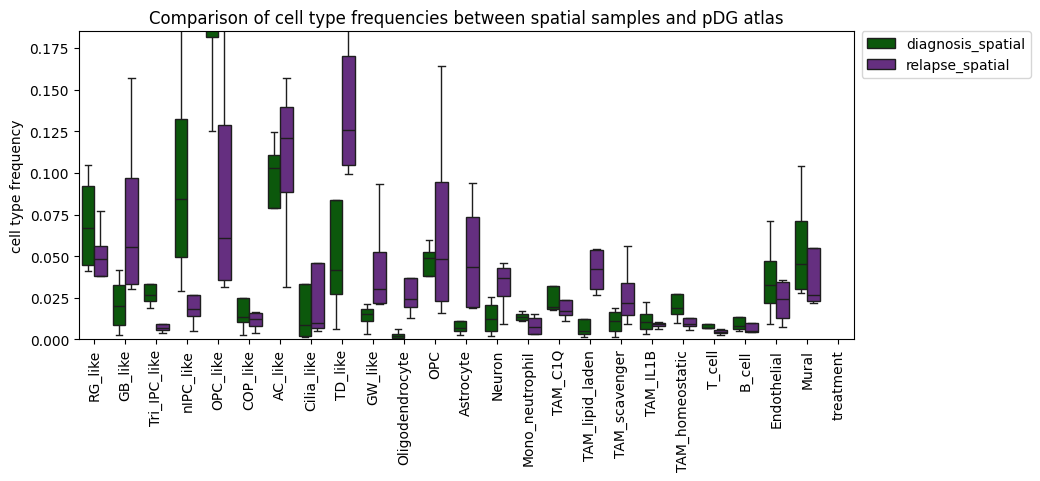

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

palette = {'diagnosis_spatial': '#006400', 'relapse_spatial': '#69218e'}

fig, ax = plt.subplots()
fig.set_size_inches(10, 4)

sb.boxplot(data=tab_bleo, hue="identifier", x="cell_type", y="value", 
           order=None, showfliers=False, hue_order=['diagnosis_spatial', 'relapse_spatial'],
           palette=palette)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel("")
plt.ylim(0, 0.185)
plt.ylabel("cell type frequency")
plt.title("Comparison of cell type frequencies between spatial samples and pDG atlas")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.savefig('figures/boxplot_cell_type_frequency_clinical_status_0.2max.pdf')
plt.show()

/scratch-local/cruiz2.8165728/ipykernel_1946442/762913189.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


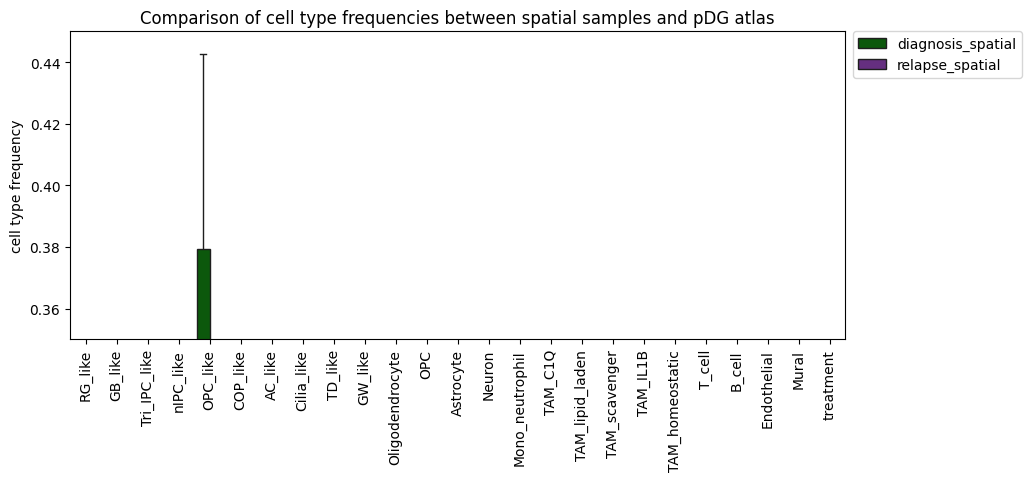

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 4)

sb.boxplot(data=tab_bleo, hue="identifier", x="cell_type", y="value", 
           order=None, showfliers=False, hue_order=['diagnosis_spatial', 'relapse_spatial'],
           palette=palette)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel("")
plt.ylim(0.35, 0.45)
plt.ylabel("cell type frequency")
plt.title("Comparison of cell type frequencies between spatial samples and pDG atlas")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.savefig('figures/boxplot_cell_type_frequency_clinical_status_0.45max.pdf')
plt.show()